In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [6]:
# importing needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings('ignore') # ignore annoying warnings

In [7]:
# load data
# check the exact path on the right side of kaggle notebook just in case
file_path = '/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv'
df = pd.read_csv(file_path)

# fix the date stuff so time series works properly later
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
df = df.sort_values(by='Date')

# forward fill any missing data so we don't break the model
df.fillna(method='ffill', inplace=True)
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


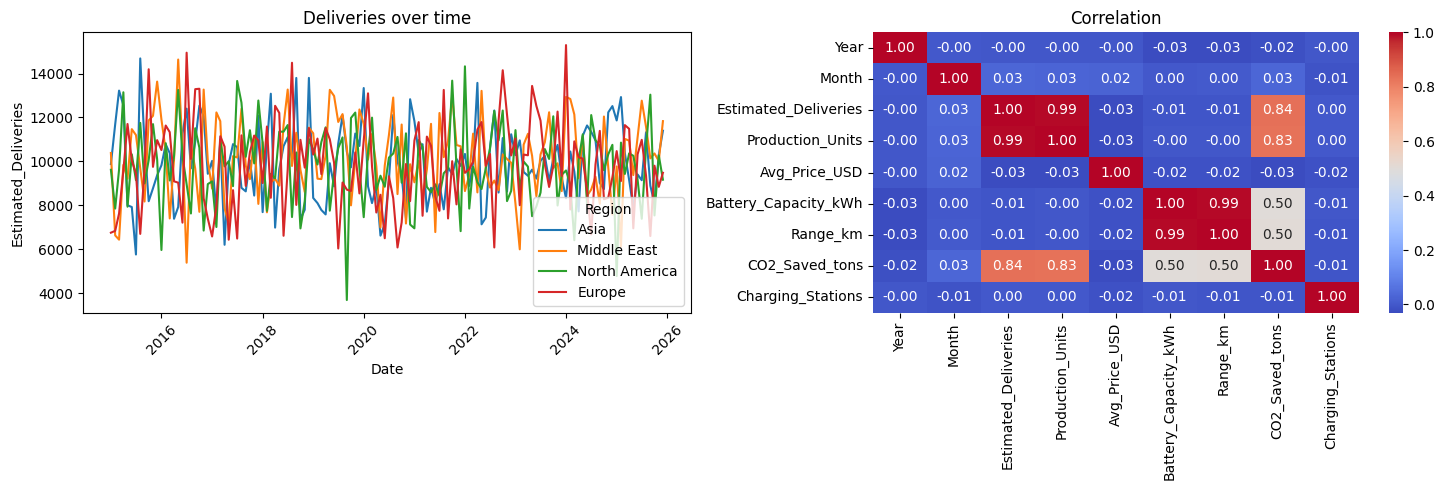

In [8]:
# basic eda - plotting deliveries and checking correlations
plt.figure(figsize=(15, 5))

# trend plot
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x='Date', y='Estimated_Deliveries', hue='Region', ci=None)
plt.title('Deliveries over time')
plt.xticks(rotation=45)

# correlation matrix
plt.subplot(1, 2, 2)
num_cols = df.select_dtypes(include=[np.number]) # only correlate numeric columns
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation')

plt.tight_layout()
plt.show()

In [9]:
# feature engineering - creating lag features to give the model historical context
df['Lag1'] = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1)
df['Lag2'] = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(2)

# drop the nans we just made with the shift function
df_ml = df.dropna().copy()

features = ['Region', 'Model', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Lag1', 'Lag2']
X = df_ml[features]
y = df_ml['Estimated_Deliveries']

# chronological train test split (not random because it's time series data)
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [10]:
# setting up the preprocessing and model pipeline
num_features = ['Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Lag1', 'Lag2']
cat_features = ['Region', 'Model']

prep = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

pipe = Pipeline([
    ('prep', prep),
    ('rf', RandomForestRegressor(random_state=42))
])

# hyperparameter tuning setup
params = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5]
}

print("training model... this might take a sec")
# using randomized search to save time over grid search
search = RandomizedSearchCV(pipe, params, cv=3, scoring='neg_mean_squared_error', n_iter=5, random_state=42)
search.fit(X_train, y_train)

best = search.best_estimator_
preds = best.predict(X_test)

print(f"best params found: {search.best_params_}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, preds):.2f}")

training model... this might take a sec
best params found: {'rf__n_estimators': 200, 'rf__min_samples_split': 2, 'rf__max_depth': 10}
RMSE: 3730.58
MAE: 2983.48


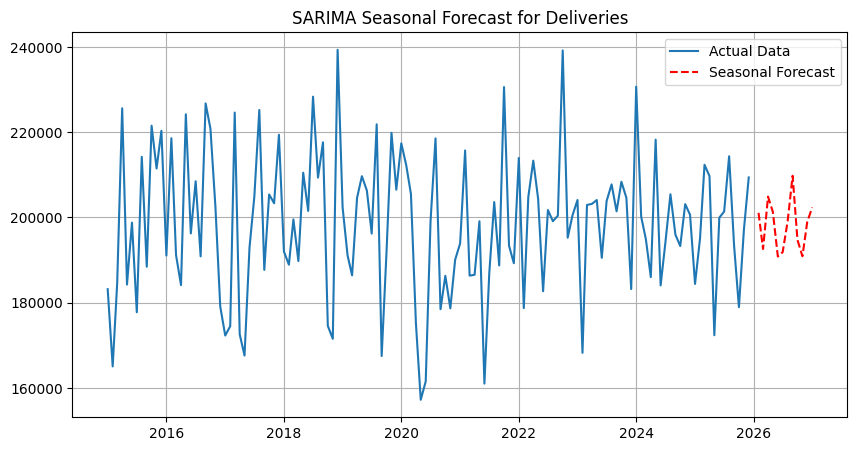

In [12]:
# cell 6 update: switching from basic arima to seasonal sarimax
from statsmodels.tsa.statespace.sarimax import SARIMAX

# grouping by date to get total global deliveries for the TS model
ts_df = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
ts_df.set_index('Date', inplace=True)

# use SARIMAX to explicitly inject a 12-month seasonal cycle
# order=(p,d,q), seasonal_order=(P,D,Q,s)
model = SARIMAX(ts_df['Estimated_Deliveries'], 
                order=(1, 1, 1), 
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit(disp=False)

# forecast next 12 months
future = results.forecast(steps=12)
future_dates = pd.date_range(start=ts_df.index[-1] + pd.DateOffset(months=1), periods=12, freq='M')

# plot the updated seasonal forecast
plt.figure(figsize=(10, 5))
plt.plot(ts_df.index, ts_df['Estimated_Deliveries'], label='Actual Data')
plt.plot(future_dates, future.values, label='Seasonal Forecast', color='red', linestyle='--')
plt.title('SARIMA Seasonal Forecast for Deliveries')
plt.legend()
plt.grid(True)
plt.show()